In [1]:
import datetime
print(f"Last updated on {datetime.date.today()}.")

Last updated on 2026-03-08.


In [2]:
# This script is used to generate the data for testing the lwa calculation in fawa. 
import numpy as np
import xarray as xr
from math import pi
from netCDF4 import Dataset
from falwa.oopinterface import QGFieldNHN22
import falwa
import os
import matplotlib.pyplot as plt
print(falwa.__version__)


# nnn 
iyear = 1986
path_example = "./"
uvt_file = xr.open_dataset(path_example+'era5_1986_09_uvt_t48_51.nc') # One only needs to change this line to read data. 

ntimes = uvt_file.time.size
time_array = uvt_file.time

# nnn 
xlon = uvt_file.longitude.values
# latitude has to be in ascending order
ylat = uvt_file.latitude.values
#ylat = uvt_file.latitude.values[:91]  # northern hemisphere only
if np.diff(ylat)[0]<0:
    print('Flip ylat.')
    ylat = ylat[::-1]

# pressure level has to be in descending order (ascending height)
plev = uvt_file.level.values
if np.diff(plev)[0]>0:
    print('Flip plev.')    
    plev = plev[::-1]

nlon = xlon.size
nlat = ylat.size
#nlat = 91 # northern hemisphere only
nlev = plev.size

clat = np.cos(np.deg2rad(ylat))     # cosine latitude
p0 = 1000.                          # surface pressure [hPa]
kmax = 49                           # number of grid points for vertical extrapolation (dimension of height)
dz = 1000.                          # differential height element
height = np.arange(0,kmax)*dz       # pseudoheight [m]
dphi = np.diff(ylat)[0]*pi/180.     # differential latitudinal element
dlambda = np.diff(xlon)[0]*pi/180.  # differential latitudinal element
hh = 7000.                          # scale height
cp = 1004.                          # heat capacity of dry air
rr = 287.                           # gas constant
omega = 7.29e-5                     # rotation rate of the earth
aa = 6.378e+6                       # earth radius
prefactor = np.array([np.exp(-z/hh) for z in height[1:]]).sum() # integrated sum of density from the level
                                                                #just above the ground (z=1km) to aloft
npart = nlat                        # number of partitions to construct the equivalent latitude grids
maxits = 100000                     # maximum number of iteration in the SOR solver to solve for reference state
tol = 1.e-5                         # tolerance that define convergence of solution
rjac = 0.95                         # spectral radius of the Jacobi iteration in the SOR solver.              
jd = nlat//2+1                      # (one plus) index of latitude grid point with value 0 deg
                                    # This is to be input to fortran code. The index convention is different.

# nnn
eq_boundary_index = 5
lwa_nh = np.zeros((ntimes, kmax, jd, nlon)) # only extract northern hemisphere results, so jd instead of nlat
qref_nh = np.zeros((ntimes, kmax, jd))
qgpv_nh = np.zeros((ntimes, kmax, jd, nlon))
# nnn
for tstep in range(0,4):  # or ntimes
    
    uu = uvt_file.variables['u'][tstep, ::-1, ::-1, :].data#[:,:91,:]
    vv = uvt_file.variables['v'][tstep, ::-1, ::-1, :].data#[:,:91,:]
    tt = uvt_file.variables['t'][tstep, ::-1, ::-1, :].data#[:,:91,:]

    qgfield_object = QGFieldNHN22(
        xlon, ylat, plev, uu, vv, tt, eq_boundary_index=eq_boundary_index, northern_hemisphere_results_only=True)
    equator_idx = qgfield_object.equator_idx

    qgfield_object.interpolate_fields(return_named_tuple=False)

    qgfield_object.compute_reference_states(return_named_tuple=False)


    qgfield_object.compute_lwa_and_barotropic_fluxes(return_named_tuple=False)
    #qgfield_object.compute_layerwise_fluxes()  # ADD THIS LINE - computes layerwise diagnostics including ep1, ep2, ep3
    out1 = qgfield_object.qgpv[1,90:,:].max()
    out2 = qgfield_object.qref[1,:].max()
    print('npac:                                                                                                              ', np.mean(qgfield_object.lwa_baro[20:61,160:201]))
    print('npac:                                                                                                              ',out1)
    print('npac:                                                                                                              ',out2)
    lwa_nh[tstep] = qgfield_object.lwa*1.
    qref_nh[tstep] = qgfield_object.qref*1.
    qgpv_nh[tstep] = qgfield_object.qgpv[:,90:,:]*1.



import os
print(falwa.__version__)

qref_nh.shape


2.3.2
Flip ylat.
Flip plev.
Do scipy interpolation
 nlon, nlat, kmax, jd
         360         181          49          91
line 748: ncforce is None
 nd:           91 , jb:            5
npac:                                                                                                               40.30383064564065
npac:                                                                                                               0.00049018563
npac:                                                                                                               0.0006908638621330261
Do scipy interpolation
 nlon, nlat, kmax, jd
         360         181          49          91
line 748: ncforce is None
 nd:           91 , jb:            5
npac:                                                                                                               1673.5563254327337
npac:                                                                                                               0.000

(4, 49, 91)

I observed unrealistically large values of lwa_baro in the selected region (where I first noticed this issue) at the second time step, 1986-09-13 06:00. I also found a similar issue at the first time step, suggesting that this might be a more widespread problem.

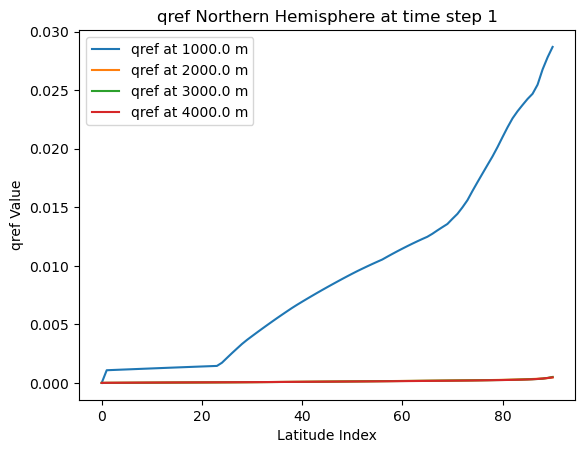

In [3]:
tstep = 1
plt.plot(qref_nh[tstep,1],color='C0',label='qref at '+str(height[1])+' m')
plt.plot(qref_nh[tstep,2],color='C1',label='qref at '+str(height[2])+' m')
plt.plot(qref_nh[tstep,3],color='C2',label='qref at '+str(height[3])+' m')
plt.plot(qref_nh[tstep,4],color='C3',label='qref at '+str(height[4])+' m')
plt.title('qref Northern Hemisphere at time step '+str(tstep))
plt.xlabel('Latitude Index')
plt.ylabel('qref Value')
plt.legend()



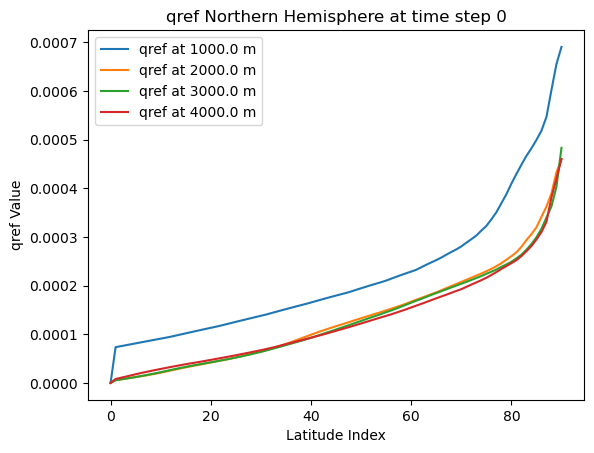

In [4]:
tstep = 0
plt.plot(qref_nh[tstep,1],color='C0',label='qref at '+str(height[1])+' m')
plt.plot(qref_nh[tstep,2],color='C1',label='qref at '+str(height[2])+' m')
plt.plot(qref_nh[tstep,3],color='C2',label='qref at '+str(height[3])+' m')
plt.plot(qref_nh[tstep,4],color='C3',label='qref at '+str(height[4])+' m')
plt.title('qref Northern Hemisphere at time step '+str(tstep))
plt.xlabel('Latitude Index')
plt.ylabel('qref Value')
plt.legend()
# The issue also appears at the first timestep, though with a smaller magnitude. This may suggest that lwa_baro could also be slightly erroneous in adjacent timesteps (just a preliminary guess).

In [5]:
# This script shows how I calculated QREF. I largely followed the Fortran code in the original FALWA, but implemented it in Python. 
# The results are stored in qref_nh_myself, which has the same shape as qref_nh. 
a       = 6.371e6
dphi    = np.deg2rad(1)
dlambda = np.deg2rad(1)
nnd     = 91
lat_nh = ylat[90:]  # northern hemisphere only

phi_nh = np.deg2rad(lat_nh)  #  (91,) 0..90 deg

qref_nh_myself = np.zeros((49, 91))
# alat: poleward area from latitude to pole (same as Fortran)
alat = 2 * np.pi * a**2 * (1 - np.sin(phi_nh))  # (91,)

for k in range(1, 48):  # skip k=0 and k=48 (boundary, stay 0)
    pv2 = qgpv_nh[tstep, k]    #  choose a specific time step and level for testing. (91, 360) lat x lon

    qmax = pv2.max()
    qmin = pv2.min()
    dq   = (qmax - qmin) / (nnd - 1)

    # Fortran-style Q bins (descending): qn(1)=qmax ... qn(nnd)=qmin
    qn = qmax - dq * np.arange(nnd)

    # Accumulate area and area-weighted PV into bins (Fortran-style indexing)
    an = np.zeros(nnd)
    cn = np.zeros(nnd)

    for j in range(91):
        cos0   = np.cos(phi_nh[j])
        da_row = a**2 * dphi * dlambda * cos0  # cell area at this lat

        # Fortran: ind = 1 + int((qmax - pv)/dq)
        inds = ((qmax - pv2[j]) / dq).astype(int) + 1

        # clamp to [1, nnd]
        inds[inds < 1]    = 1
        inds[inds > nnd]  = nnd

        ib = inds - 1  # to 0-based

        np.add.at(an, ib, da_row)
        np.add.at(cn, ib, da_row * pv2[j])

    # Fortran cumulative:
    # aan(1)=0; ccn(1)=0
    # do nn=2,nnd: aan(nn)=aan(nn-1)+an(nn); ccn(nn)=ccn(nn-1)+cn(nn)
    aan = np.zeros(nnd)
    ccn = np.zeros(nnd)
    for nn in range(1, nnd):
        aan[nn] = aan[nn-1] + an[nn]
        ccn[nn] = ccn[nn-1] + cn[nn]

    # Fortran bracket search + linear interpolation:
    # do j=1,nd-1
    #   do nn=1,nnd-1
    #     if(aan(nn)<=alat(j) .and. aan(nn+1)>alat(j)) then ...
    for j in range(0, 90):          # Python: 0..89 corresponds to Fortran j=1..nd-1
        Aj = alat[j]
        for nn in range(0, nnd-1):  # Python: 0..nnd-2 corresponds to Fortran nn=1..nnd-1
            if (aan[nn] <= Aj) and (aan[nn+1] > Aj):
                dd = (Aj - aan[nn]) / (aan[nn+1] - aan[nn])
                qref_nh_myself[k, j] = qn[nn] * (1 - dd) + qn[nn+1] * dd
                break

    # Fortran: qref(nd,k) = qmax  (nd=91 -> index 90)
    qref_nh_myself[k, 90] = qmax
    


In [6]:
qgpv_nh.shape

(4, 49, 91, 360)

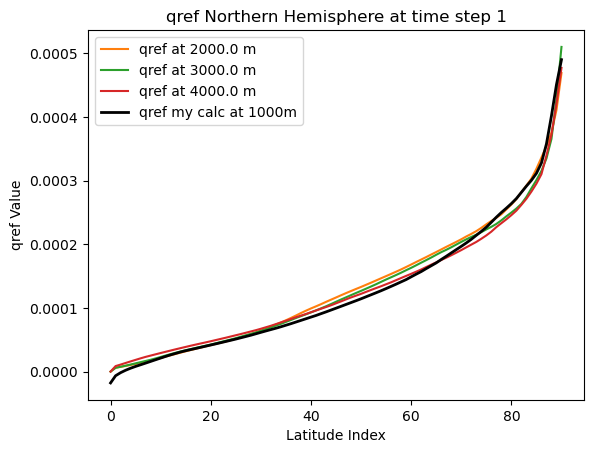

In [7]:
# This suggests that the qref we calculated ourselves (qref_nh_myself) is very close to the qref from the original code (qref_nh) at the upper levels, which is a good sign. 
tstep = 1
#plt.plot(qref_nh[tstep,1],color='C0',label='qref at '+str(height[1])+' m')
plt.title('qref Northern Hemisphere at time step '+str(tstep))
plt.plot(qref_nh[tstep,2],color='C1',label='qref at '+str(height[2])+' m')
plt.plot(qref_nh[tstep,3],color='C2',label='qref at '+str(height[3])+' m')
plt.plot(qref_nh[tstep,4],color='C3',label='qref at '+str(height[4])+' m')
plt.plot(qref_nh_myself[1],color='k',linewidth=2, label = 'qref my calc at 1000m')

plt.xlabel('Latitude Index')
plt.ylabel('qref Value')
plt.legend()



In [8]:
# This script shows I then calculated the lwa using the qgpv and qref we have, following the logic in the Fortran code. 
# The function lwa_nh_numba is accelerated with Numba for speed. The results are stored in lwa_nh_calc, 
# which has the same shape as lwa_nh. We can compare lwa_nh_calc with lwa_nh to see if they match (they should match very closely if everything is correct).
from numba import njit, prange

# -------------------------------------------------
# Numba-accelerated LWA (NH) — same logic as Fortran
# qgpv_nh: (kmax, nd, imax)
# qref_nh: (kmax, nd)
# returns: (kmax, nd, imax)
# -------------------------------------------------
@njit(parallel=True, fastmath=False)
def lwa_nh_numba(qgpv_nh, qref_nh, a, dp):
    kmax, nd, imax = qgpv_nh.shape
    lwa = np.zeros((kmax, nd, imax), dtype=qgpv_nh.dtype)

    for k in prange(1, kmax - 1):          # skip top/bottom like Fortran
        for i in range(imax):
            for j in range(1, nd - 1):
                astar1 = 0.0
                astar2 = 0.0

                for jj in range(nd):
                    phi1 = dp * jj
                    qe = qgpv_nh[k, jj, i] - qref_nh[k, j]
                    aa = a * dp * np.cos(phi1)

                    if (qe <= 0.0) and (jj >= j):
                        astar2 -= qe * aa
                    if (qe > 0.0) and (jj < j):
                        astar1 += qe * aa

                lwa[k, j, i] = astar1 + astar2

    return lwa


# -----------------------------
# example usage (your shapes)
# -----------------------------
a = 6.371e6
dp = np.pi / 180.0

# ensure contiguous arrays for speed
qgpv_nh_calc = np.ascontiguousarray(qgpv_nh[tstep])
qref_nh_calc = np.ascontiguousarray(qref_nh_myself) #[tstep]  # use the qref we calculated ourselves for testing

lwa_nh_calc = lwa_nh_numba(qgpv_nh_calc, qref_nh_calc, a, dp)



OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [9]:
qref_nh_myself.shape

(49, 91)

In [10]:
lwa_nh_calc.shape

(49, 91, 360)

In [11]:
# The calculated lwa_nh_calc appears realistic compared to the one produced by FALWA (shown in the next plot).
plt.figure(figsize=(12,6))
plt.contourf(xlon, ylat[90:],lwa_nh_calc[z], 20, cmap='jet',extend='both')
plt.axhline(y=0, c='w', lw=30)
plt.ylabel('Latitude (deg)')
plt.xlabel('Longitude (deg)')
plt.colorbar()
#plt.title(variables_xy[5][1] +' | ' + str(tstamp[tstep]))
plt.show()

NameError: name 'z' is not defined

<Figure size 1200x600 with 0 Axes>

In [ ]:
plt.figure(figsize=(12,6))
plt.contourf(xlon, ylat[90:],lwa_nh[tstep,z], 20, cmap='jet',extend='both')
plt.axhline(y=0, c='w', lw=30)
plt.ylabel('Latitude (deg)')
plt.xlabel('Longitude (deg)')
plt.colorbar()
#plt.title(variables_xy[5][1] +' | ' + str(tstamp[tstep]))
plt.show()